# Samdé : Analyse & Modélisation du Scoring Microcrédit
**Hackathon National d'Innovation CIF Projet DigiCoop-WA+ | Thématique 02 : Scoring Microcrédit**

Ce notebook documente le pipeline complet : génération/chargement des données,
analyse exploratoire, prétraitement, gestion du déséquilibre des classes (SMOTE),
comparaison de 3 modèles et explicabilité (SHAP).


In [1]:
import warnings
warnings.filterwarnings("ignore")
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)


## 1. Chargement des données

Jeu de données synthétique calibré sur le contexte des Coopératives financières d'Afrique de l'Ouest (voir `scripts/01_generate_dataset.py` pour la méthodologie de génération).

In [2]:
df = pd.read_csv("../data/samde_dataset.csv")
print(df.shape)
df.head()


(4000, 30)


,id_client,age,sexe,zone,situation_matrimoniale,niveau_education,nombre_personnes_a_charge,secteur_activite,anciennete_activite_annees,revenu_mensuel_fcfa,charges_mensuelles_fcfa,anciennete_cooperative_mois,membre_groupe_solidaire,epargne_solde_moyen_fcfa,regularite_epargne,nombre_credits_anterieurs,taux_remboursement_historique_pct,jours_retard_moyen_historique,possede_mobile_money,frequence_transactions_mm_mois,interroge_bic,statut_bic,nombre_prets_actifs_autres_institutions,encours_credit_autres_institutions_fcfa,objet_credit,montant_credit_demande_fcfa,duree_credit_mois,garantie,ratio_endettement,defaut_credit
0,SMD-00001,23,Femme,Rurale,Célibataire,Primaire,3,Artisanat,3.2,67000,49000,40,0,18400,Irrégulière,2,83.1,8.0,1,8,1,Pret en cours ailleurs,1,121000,Habitat/Réparation,188000,6,Aucune,1.42,0
1,SMD-00002,55,Femme,Urbaine,Célibataire,Secondaire,4,Commerce informel,6.0,103000,66000,161,0,70300,Irrégulière,1,72.3,16.0,1,10,1,Bon payeur ailleurs (solde sans incident),0,0,Santé,221000,12,Caution solidaire,0.84,0
2,SMD-00003,49,Femme,Rurale,Marié(e),Secondaire,3,Restauration/Transformation,1.5,85000,30000,6,1,6800,Irrégulière,2,80.2,1.0,1,13,1,Jamais emprunté ailleurs,0,0,Fonds de commerce,153000,24,Aucune,0.44,0
3,SMD-00004,39,Femme,Urbaine,Marié(e),Aucun,1,Fonctionnaire,6.3,128000,92000,53,1,31000,Régulière,2,41.5,7.0,1,8,0,Non consulté,0,0,Habitat/Réparation,374000,18,Aucune,0.90,0
4,SMD-00005,39,Homme,Urbaine,Marié(e),Aucun,7,Restauration/Transformation,5.1,104000,58000,116,1,55900,Irrégulière,2,78.3,3.0,1,14,1,Jamais emprunté ailleurs,0,0,Fonds de commerce,269000,6,Aucune,1.04,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 30 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id_client                                4000 non-null   str    
 1   age                                      4000 non-null   int64  
 2   sexe                                     4000 non-null   str    
 3   zone                                     4000 non-null   str    
 4   situation_matrimoniale                   4000 non-null   str    
 5   niveau_education                         4000 non-null   str    
 6   nombre_personnes_a_charge                4000 non-null   int64  
 7   secteur_activite                         4000 non-null   str    
 8   anciennete_activite_annees               4000 non-null   float64
 9   revenu_mensuel_fcfa                      4000 non-null   int64  
 10  charges_mensuelles_fcfa                  4000 non-null   in

## 2. Analyse exploratoire (EDA)

Taux de défaut global : 12.65%


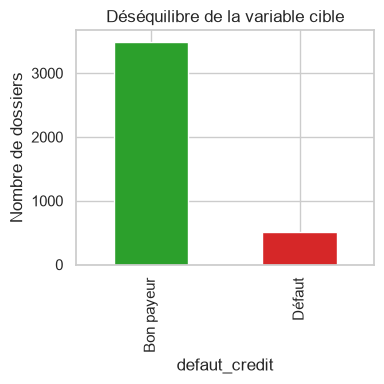

In [4]:
taux_defaut = df['defaut_credit'].mean()
print(f"Taux de défaut global : {taux_defaut:.2%}")

fig, ax = plt.subplots(figsize=(4,4))
df['defaut_credit'].value_counts().rename({0:'Bon payeur',1:'Défaut'}).plot(
    kind='bar', color=['#2ca02c','#d62728'], ax=ax)
ax.set_title("Déséquilibre de la variable cible")
ax.set_ylabel("Nombre de dossiers")
plt.tight_layout()
plt.show()


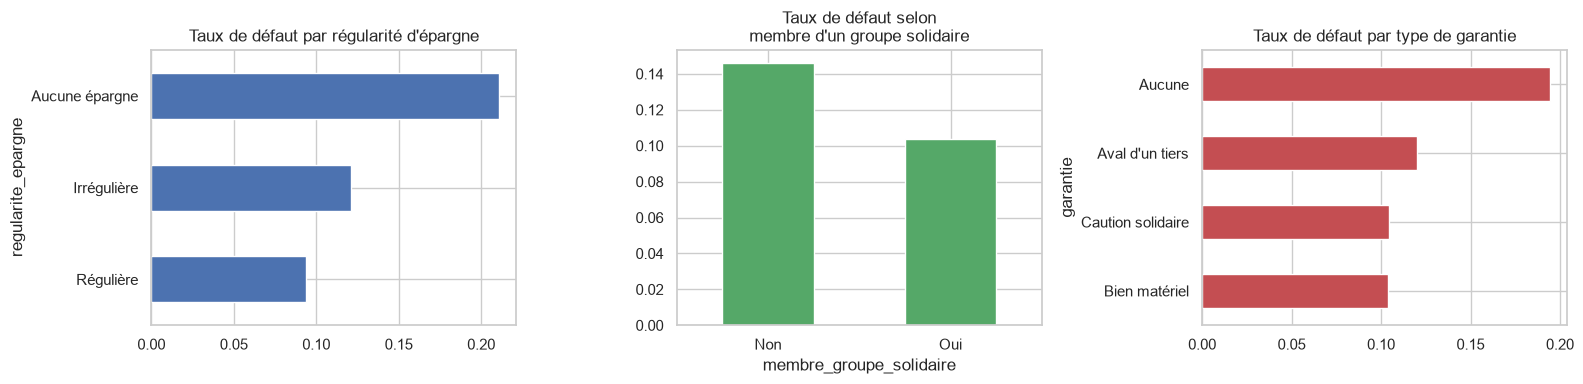

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))

df.groupby('regularite_epargne')['defaut_credit'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title("Taux de défaut par régularité d'épargne")

df.groupby('membre_groupe_solidaire')['defaut_credit'].mean().rename(
    {0:'Non',1:'Oui'}).plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title("Taux de défaut selon\nmembre d'un groupe solidaire")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

df.groupby('garantie')['defaut_credit'].mean().sort_values().plot(
    kind='barh', ax=axes[2], color='#C44E52')
axes[2].set_title("Taux de défaut par type de garantie")

plt.tight_layout()
plt.show()


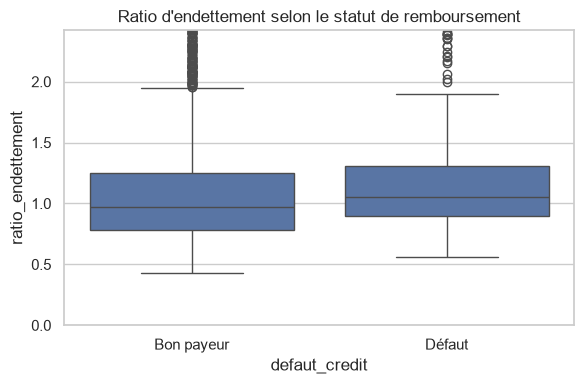

In [6]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df, x='defaut_credit', y='ratio_endettement', ax=ax)
ax.set_xticklabels(['Bon payeur','Défaut'])
ax.set_title("Ratio d'endettement selon le statut de remboursement")
ax.set_ylim(0, df['ratio_endettement'].quantile(0.98))
plt.tight_layout()
plt.show()


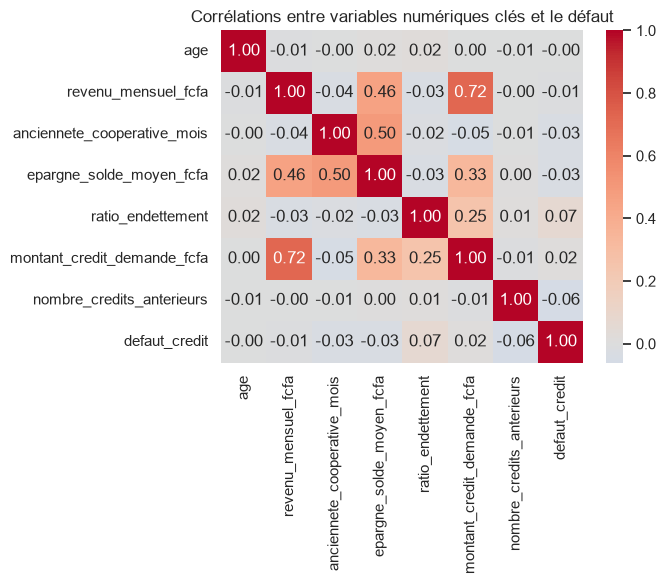

In [7]:
num_cols_eda = ['age','revenu_mensuel_fcfa','anciennete_cooperative_mois',
                'epargne_solde_moyen_fcfa','ratio_endettement','montant_credit_demande_fcfa',
                'nombre_credits_anterieurs','defaut_credit']
corr = df[num_cols_eda].corr()
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Corrélations entre variables numériques clés et le défaut")
plt.tight_layout()
plt.show()


**Lecture rapide de l'EDA :**
- L'absence d'épargne régulière, l'absence de garantie et l'absence de cautionnement
  solidaire sont associées à un taux de défaut nettement plus élevé.
- Le ratio d'endettement est plus élevé et plus dispersé chez les clients en défaut.
- Les corrélations linéaires simples restent modérées : cela justifie le recours à des
  modèles capables de capter des interactions (Random Forest, XGBoost), comparés ici
  à une régression logistique de référence.


## 3. Prétraitement, séparation train/test et SMOTE

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

TARGET = "defaut_credit"
X = df.drop(columns=["id_client", TARGET])
y = df[TARGET]

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                       ("scaler", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print("Avant SMOTE :", dict(y_train.value_counts()))
X_train_res, y_train_res = SMOTE(random_state=42).fit_resample(X_train_proc, y_train)
print("Après SMOTE :", dict(pd.Series(y_train_res).value_counts()))


Avant SMOTE : {0: np.int64(2795), 1: np.int64(405)}
Après SMOTE : {0: np.int64(2795), 1: np.int64(2795)}


  File "C:\Users\savad\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\savad\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\savad\AppData\Local\Python\pythoncore-3.14-64\Lib\subprocess.py", line 555, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\savad\AppData\Local\Python\pythoncore-3.14-64\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^

## 4. Comparaison de 3 modèles de classification

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score, f1_score,
                              recall_score, accuracy_score, precision_recall_curve,
                              roc_curve)

models = {
    "Regression_Logistique": LogisticRegression(max_iter=2000, random_state=42),
    "Random_Forest": RandomForestClassifier(n_estimators=300, max_depth=10,
                                             min_samples_leaf=5, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.06,
                              subsample=0.9, colsample_bytree=0.9,
                              eval_metric="logloss", random_state=42, n_jobs=-1),
}

def best_f1_threshold(y_true, proba):
    p, r, t = precision_recall_curve(y_true, proba)
    f1 = 2*p*r/(p+r+1e-9)
    idx = np.argmax(f1[:-1])
    return float(t[idx]), float(f1[idx])

results, fitted, probas = {}, {}, {}
for name, m in models.items():
    m.fit(X_train_res, y_train_res)
    proba = m.predict_proba(X_test_proc)[:,1]
    probas[name] = proba
    pred05 = (proba >= 0.5).astype(int)
    thr, f1opt = best_f1_threshold(y_test, proba)
    results[name] = {
        "accuracy@0.5": round(accuracy_score(y_test, pred05),4),
        "recall_defaut@0.5": round(recall_score(y_test, pred05),4),
        "f1_defaut@0.5": round(f1_score(y_test, pred05),4),
        "roc_auc": round(roc_auc_score(y_test, proba),4),
        "seuil_optimal": round(thr,3),
        "f1_defaut@seuil_optimal": round(f1opt,4),
    }
    fitted[name] = m

results_df = pd.DataFrame(results).T
results_df


,accuracy@0.5,recall_defaut@0.5,f1_defaut@0.5,roc_auc,seuil_optimal,f1_defaut@seuil_optimal
Regression_Logistique,0.6637,0.6337,0.3224,0.7095,0.536,0.3536
Random_Forest,0.8738,0.0594,0.1062,0.7023,0.332,0.3385
XGBoost,0.8700,0.0693,0.1186,0.7176,0.290,0.3478


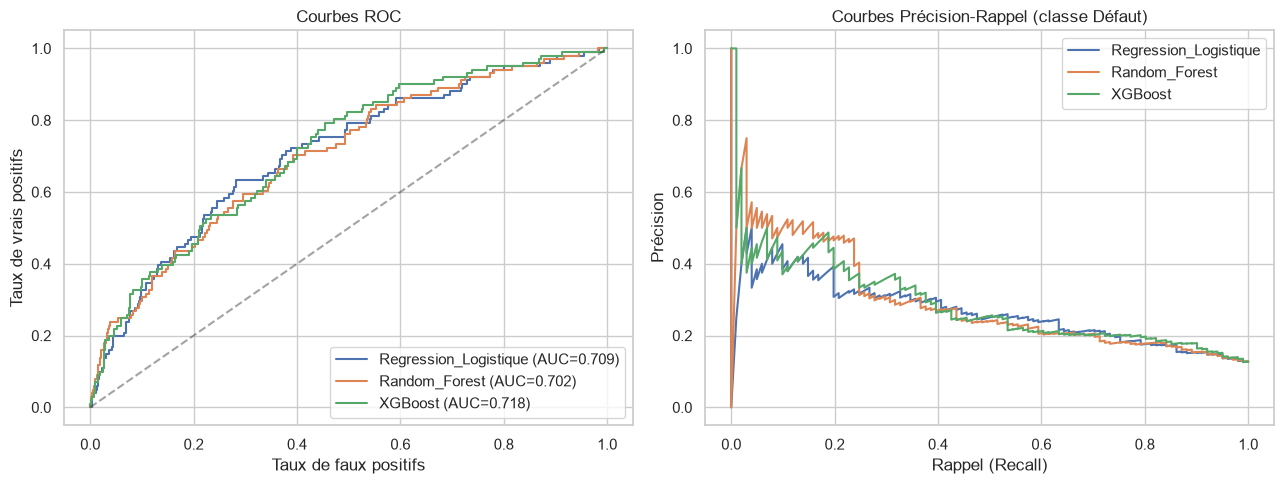

In [10]:
fig, axes = plt.subplots(1,2, figsize=(13,5))
for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test,proba):.3f})")
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel("Taux de faux positifs"); axes[0].set_ylabel("Taux de vrais positifs")
axes[0].set_title("Courbes ROC"); axes[0].legend()

for name, proba in probas.items():
    p, r, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(r, p, label=name)
axes[1].set_xlabel("Rappel (Recall)"); axes[1].set_ylabel("Précision")
axes[1].set_title("Courbes Précision-Rappel (classe Défaut)"); axes[1].legend()
plt.tight_layout(); plt.show()


**Critère de sélection du modèle final :** compte tenu du fort déséquilibre des classes
(≈88% bons payeurs) et du coût métier asymétrique, accorder un crédit à un mauvais
payeur (faux négatif) coûte bien plus cher à la coopérative qu'un bon dossier refusé
à tort (faux positif) alors le modèle est sélectionné sur le **F1-score de la classe
"Défaut" au seuil de décision optimisé**, et non sur l'accuracy globale  considére comme trompeuse
ici ni sur le seuil par défaut de 0.5.


In [11]:
best_name = max(results, key=lambda k: results[k]["f1_defaut@seuil_optimal"])
best_model = fitted[best_name]
print("Modèle retenu :", best_name)
print(classification_report(y_test, (probas[best_name] >= 0.5).astype(int),
                             target_names=["Bon payeur","Défaut"]))


Modèle retenu : Regression_Logistique
              precision    recall  f1-score   support

  Bon payeur       0.93      0.67      0.78       699
      Défaut       0.22      0.63      0.32       101

    accuracy                           0.66       800
   macro avg       0.57      0.65      0.55       800
weighted avg       0.84      0.66      0.72       800



## 5. Explicabilité globale (SHAP) du modèle retenu

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


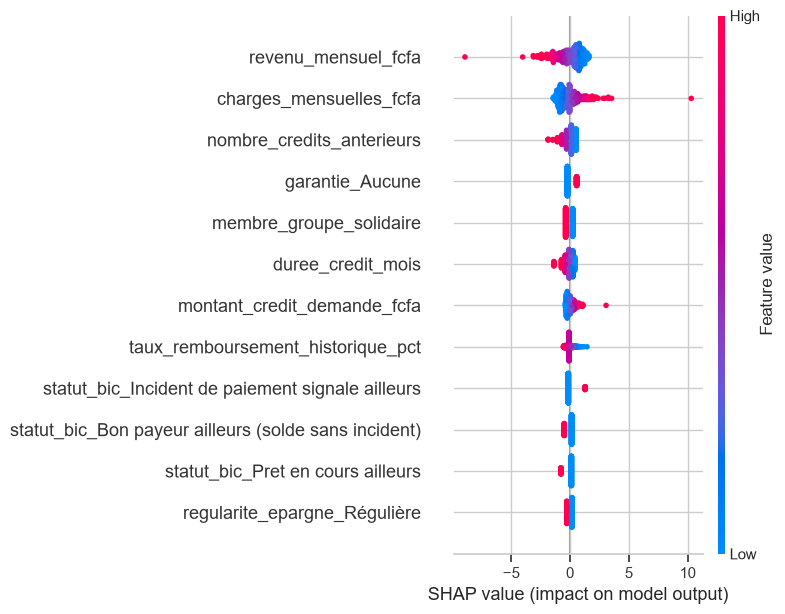

In [12]:
import shap

feature_names = num_cols + list(
    preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(cat_cols))

background_idx = np.random.RandomState(42).choice(X_train_res.shape[0], size=200, replace=False)
X_background = X_train_res[background_idx]

if best_name == "Regression_Logistique":
    explainer = shap.LinearExplainer(best_model, X_background)
else:
    explainer = shap.TreeExplainer(best_model)

sample_idx = np.random.RandomState(42).choice(X_test_proc.shape[0], size=min(300, X_test_proc.shape[0]), replace=False)
X_sample = X_test_proc[sample_idx]
if hasattr(X_sample, "toarray"):
    X_sample = X_sample.toarray()

shap_values = explainer.shap_values(X_sample)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

fig = plt.figure(figsize=(8,6))
shap.summary_plot(sv, X_sample, feature_names=feature_names, show=False, max_display=12)
plt.tight_layout()
plt.show()


Ce graphique répond à l'exigence d'**explicabilité** du dossier de candidature :
chaque point représente un dossier test, sa couleur la valeur de la variable, et sa
position l'impact sur le score de risque. On y retrouve les intuitions métier de
l'EDA (régularité de l'épargne, garantie, cautionnement solidaire, ancienneté,
ratio d'endettement) — ce qui renforce la confiance des agents de crédit dans le
modèle, un point critique pour l'adoption opérationnelle en Coopérative financière.


## 6. Scorecard : score de crédit, WoE/IV et perte attendue (Expected Loss)

Au-delà de la probabilité brute, le secteur du crédit utilise deux compléments
standards que nous reproduisons ici, adaptés à notre contexte (FCFA, garanties
locales) plutôt qu'empruntés tels quels à un score bancaire occidental :

- le **Weight of Evidence / Information Value (WoE/IV)**, qui mesure le pouvoir
  discriminant de chaque variable numérique de façon indépendante du modèle . un
  bon complément de validation à SHAP ;
- la conversion de la probabilité en **score à points (300-900)**, plus lisible
  pour un agent qu'un pourcentage brut ;
- la **perte attendue (Expected Loss = PD × LGD × EAD)**, qui traduit le risque
  en FCFA plutôt qu'en probabilité abstraite, avec un LGD qui dépend du type de
  garantie proposée par le client.


In [13]:
def information_value(frame, col, target, n=8):
    d = frame[[col, target]].copy()
    d[col] = d[col].fillna(d[col].median())
    try:
        d['bin'] = pd.qcut(d[col], q=n, duplicates='drop')
    except ValueError:
        d['bin'] = pd.cut(d[col], bins=5)
    total_good = (d[target] == 0).sum()
    total_bad = (d[target] == 1).sum()
    g = d.groupby('bin', observed=True)[target].agg(['sum', 'count'])
    g.columns = ['bads', 'total']
    g['goods'] = g['total'] - g['bads']
    g['dist_good'] = g['goods'] / (total_good + 1e-9)
    g['dist_bad'] = g['bads'] / (total_bad + 1e-9)
    g['woe'] = np.log((g['dist_good'] + 1e-9) / (g['dist_bad'] + 1e-9))
    g['iv'] = (g['dist_good'] - g['dist_bad']) * g['woe']
    return g['iv'].sum()

iv_cols = ['age', 'revenu_mensuel_fcfa', 'anciennete_cooperative_mois',
           'epargne_solde_moyen_fcfa', 'ratio_endettement', 'montant_credit_demande_fcfa',
           'nombre_credits_anterieurs', 'nombre_personnes_a_charge']
iv_results = pd.Series({c: information_value(df, c, TARGET) for c in iv_cols}).sort_values(ascending=False)

def iv_power(v):
    return ('Forte' if v > 0.3 else 'Modérée' if v > 0.1 else 'Faible' if v > 0.02 else 'Inutile')

iv_table = iv_results.to_frame('IV')
iv_table['Pouvoir discriminant'] = iv_table['IV'].apply(iv_power)
iv_table


,IV,Pouvoir discriminant
ratio_endettement,0.190336,Modérée
revenu_mensuel_fcfa,0.031834,Faible
anciennete_cooperative_mois,0.030742,Faible
nombre_credits_anterieurs,0.016783,Inutile
montant_credit_demande_fcfa,0.016083,Inutile
nombre_personnes_a_charge,0.014041,Inutile
epargne_solde_moyen_fcfa,0.010254,Inutile
age,0.007462,Inutile


**Lecture :** le ratio d'endettement et l'ancienneté à la coopérative sont les variables numériques les plus discriminantes prises isolément ce qui est cohérent avec le classement SHAP obtenu par le modèle complet, ce qui valide le signal de façon indépendante.

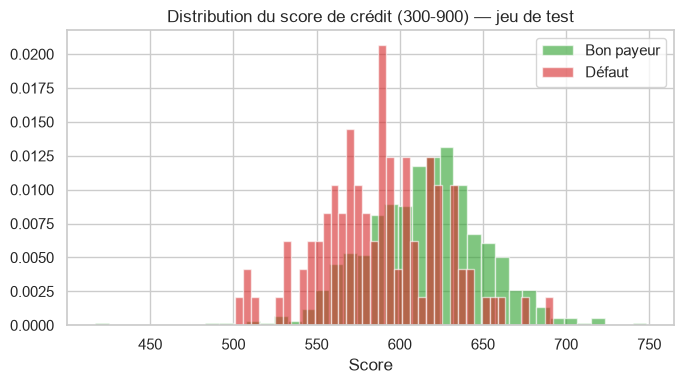

In [14]:
# Conversion probabilité -> score à points (convention scorecard standard)
PDO, BASE, ODDS = 20, 600, 1.0
facteur = PDO / np.log(2)
offset = BASE - facteur * np.log(ODDS)

def proba_vers_score(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.clip(offset + facteur * np.log((1 - p) / p), 300, 900)

scores_test = proba_vers_score(probas[best_name])

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(scores_test[y_test.values==0], bins=40, alpha=0.6, color='#2ca02c', label='Bon payeur', density=True)
ax.hist(scores_test[y_test.values==1], bins=40, alpha=0.6, color='#d62728', label='Défaut', density=True)
ax.set_title("Distribution du score de crédit (300-900) — jeu de test")
ax.set_xlabel("Score"); ax.legend()
plt.tight_layout(); plt.show()


In [15]:
# Perte attendue (Expected Loss) sur le jeu de test, LGD dépendant de la garantie
LGD_PAR_GARANTIE = {"Bien matériel": 0.35, "Aval d'un tiers": 0.45,
                     "Caution solidaire": 0.40, "Aucune": 0.65}

test_res = X_test.copy()
test_res['proba_defaut'] = probas[best_name]
test_res['score'] = scores_test
test_res['lgd'] = test_res['garantie'].map(LGD_PAR_GARANTIE).fillna(0.55)
test_res['ead'] = test_res['montant_credit_demande_fcfa']
test_res['expected_loss_fcfa'] = test_res['proba_defaut'] * test_res['lgd'] * test_res['ead']

print(f"Perte attendue totale sur le jeu de test : {test_res['expected_loss_fcfa'].sum():,.0f} FCFA")
print(f"Perte attendue moyenne par dossier        : {test_res['expected_loss_fcfa'].mean():,.0f} FCFA")

test_res['bucket'] = pd.cut(test_res['proba_defaut'], bins=[0, 0.15, 0.35, 0.60, 1.0],
                             labels=['Faible', 'Modéré', 'Élevé', 'Critique'])
test_res.groupby('bucket', observed=True).agg(
    nb_dossiers=('proba_defaut', 'count'),
    pd_moyenne=('proba_defaut', 'mean'),
    el_moyenne_fcfa=('expected_loss_fcfa', 'mean'),
    el_totale_fcfa=('expected_loss_fcfa', 'sum'),
)


Perte attendue totale sur le jeu de test : 48,617,827 FCFA
Perte attendue moyenne par dossier        : 60,772 FCFA


,nb_dossiers,pd_moyenne,el_moyenne_fcfa,el_totale_fcfa
bucket,,,,
Faible,111,0.092608,13458.569427,1.493901e+06
Modéré,245,0.252234,32821.517381,8.041272e+06
Élevé,246,0.470192,59795.974786,1.470981e+07
Critique,198,0.754651,123095.172612,2.437284e+07


**Lecture :** cette table donne au comité de crédit un chiffre directement actionnable : combien de FCFA de pertes attendues représente chaque tranche de risque, plutôt qu'une probabilité seule. C'est ce même calcul qui alimente l'indicateur « Perte attendue estimée » affiché dans l'application Streamlit pour chaque dossier.

## 7. Sauvegarde des artefacts pour l'application Streamlit

*(déjà réalisée par `scripts/02_train_model.py` — cellule reproduite ici à titre de traçabilité)*

In [16]:
import os
os.makedirs("../models", exist_ok=True)
joblib.dump(preprocessor, "../models/preprocessor.pkl")
joblib.dump(best_model, "../models/best_model.pkl")
joblib.dump(feature_names, "../models/feature_names.pkl")
joblib.dump(num_cols, "../models/num_cols.pkl")
joblib.dump(cat_cols, "../models/cat_cols.pkl")
joblib.dump(X_background, "../models/shap_background.pkl")
print("Artefacts (ré)sauvegardés.")


Artefacts (ré)sauvegardés.


## 8. Conclusion

Le modèle retenu, entraîné sur des variables réalistes et disponibles localement (épargne, historique interne, Mobile Money, BIC, cautionnement solidaire), atteint des performances raisonnables sur données simulées et fournit une explication dossier-par-dossier (SHAP) ainsi qu'une traduction en score et en perte attendue en FCFA (scorecard), compatibles avec les contraintes opérationnelles (connectivité limitée, besoin de transparence des agents de crédit) des Coopératives financières membres de la CIF. Prochaine étape : recalibrage sur données réelles anonymisées lors du déploiement pilote.